In [1]:
import EFC_learningfMRI.util as util
import EFC_learningfMRI.globals as gl
import os
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import EFC_learningfMRI.vis as vis
import pandas as pd
import seaborn as sb
import itertools
import statsmodels.formula.api as smf

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


# Crossnobis dissimilarities in absolute force and absolute force derivative
The RDMs show an example participant

In [2]:
# pick one example participant and list the chords they trained
sn     = 103                        
chords = util.get_trained_and_untrained(sn)
path   = os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}')

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

print(f'subj{sn}: trained {chords[:4]}, untrained {chords[4:]}')

subj103: trained ['92122', '21911', '12291', '21291'], untrained ['91211', '22911', '12129', '11911']


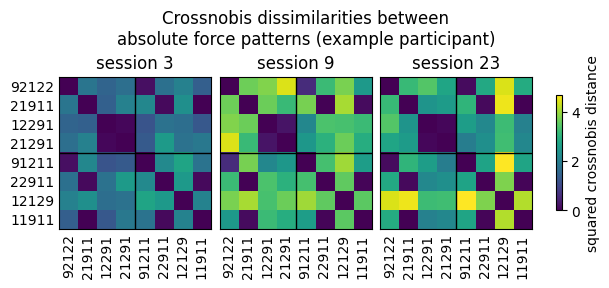

In [3]:
metric = 'abs'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

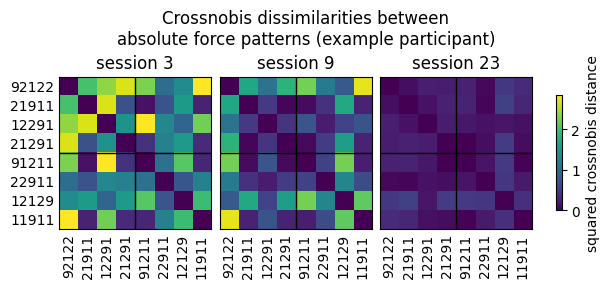

In [4]:
# example participant: dissimilarities between absolute force derivative patterns, one matrix per session

metric = 'der'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

# Average crossnobis dissimilarities and angles between trained and untrained chords 
## Absolute force

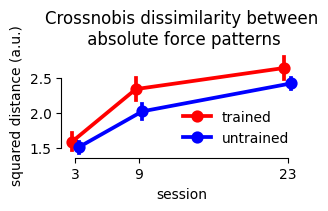

In [5]:
dist_force = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity.within_session.force.tsv'), sep='\t')
dist_force = dist_force[dist_force.chord.isin(hue_order)]
dist_force_g = dist_force.groupby(['sn', 'session', 'chord', 'metric']).mean(numeric_only=True).reset_index()
dist_force_g.session = dist_force_g.session.astype(int)

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=ax, trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\n absolute force patterns')

plt.show()

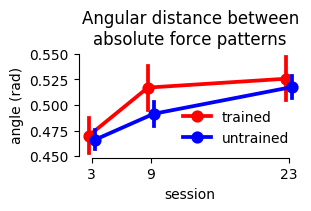

In [6]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='abs'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force patterns')

plt.show()

## Absolute force derivative

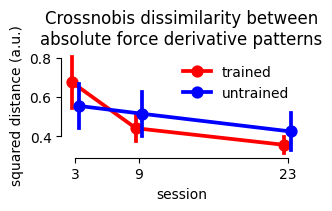

In [7]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity between\nabsolute force derivative patterns')

plt.show()

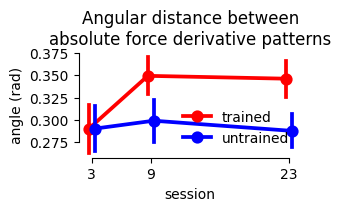

In [8]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_force_g[dist_force_g.metric=='der'], x='session', y='theta', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1, native_scale=True)
ax.set_xticks(gl.sessions)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('angle (rad)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Angular distance between\nabsolute force derivative patterns')

plt.show()

# Intercept analysis

The angular distance between absolute force derivative patterns (and to a lesser degree the crossnobis distance between absolute force patterns) showed pattern separation that was stronger in traned vs. untrained chords. A linear regression was fitted across participants between the average angle difference (trained - untrained) in neural activity patterns and asbolute force derivative patterns. A similar analysis was performed between average crossnobis dissimilarity difference (trained - untrained) in neural activity patterns and asbolute force patterns. The intercept in session 23 was significant in M1 and S1, suggesting a genuine pattern separation in this regions.

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3  -0.005250 -0.019940  0.009440 -0.772086  0.453871
3         PMd        3  -0.002617 -0.018583  0.013349 -0.354107  0.728936
6         PMv        3  -0.005705 -0.034348  0.022939 -0.430268  0.674047
9          M1        3  -0.009353 -0.053453  0.034746 -0.458203  0.654372
12         S1        3  -0.016207 -0.050483  0.018069 -1.021526  0.325640
15       SPLa        3  -0.016854 -0.049270  0.015562 -1.123258  0.281644
18       SPLp        3  -0.014553 -0.050262  0.021156 -0.880458  0.394597
1         SMA        9   0.004511 -0.022886  0.031908  0.355708  0.727765
4         PMd        9  -0.013950 -0.043693  0.015793 -1.013234  0.329436
7         PMv        9  -0.002412 -0.040974  0.036151 -0.135113  0.894592
10         M1        9   0.012101 -0.036926  0.061129  0.533235  0.602868
13         S1        9   0.005893 -0.046845  0.058630  0.241387  0.813020
16       SPLa        9   0.000934 -0.0

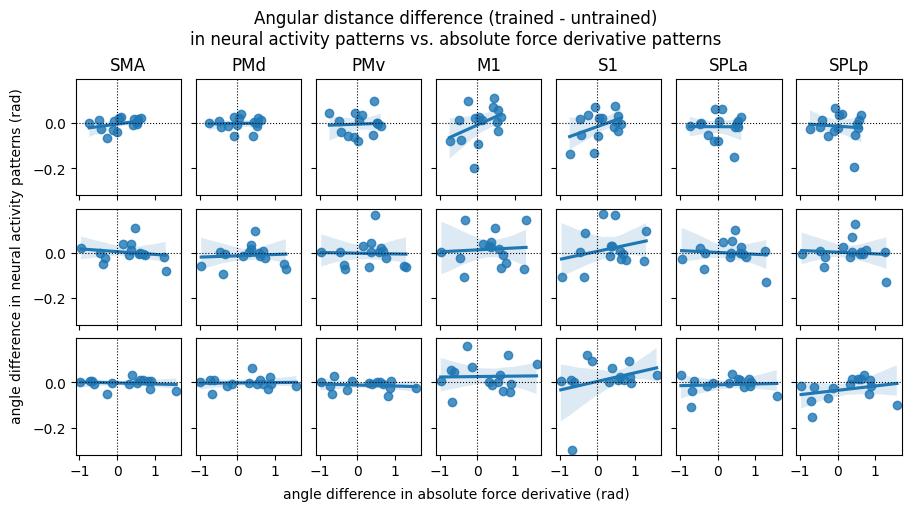

In [9]:
# difference in neural dissimilarities
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'crossnobis'
dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.chord.isin(hue_order))]
dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
dist_neural_trained   = dist_neural_g[dist_neural_g.chord=='trained'].reset_index(drop=True)
dist_neural_untrained = dist_neural_g[dist_neural_g.chord=='untrained'].reset_index(drop=True)
diff_neural         = dist_neural_trained.copy()
diff_neural         = diff_neural.merge(dist_neural_untrained, on=['session', 'sn', 'roi', 'Hem'])
diff_neural['Diff'] = diff_neural[f'{stat}_x'] - diff_neural[f'{stat}_y']

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='abs']
dist_force_trained   = dist_force_g_der[dist_force_g_der.chord=='trained'].reset_index(drop=True)
dist_force_untrained = dist_force_g_der[dist_force_g_der.chord=='untrained'].reset_index(drop=True)
diff_force         = dist_force_trained.copy()
diff_force         = diff_force.merge(dist_force_untrained, on=['session', 'sn',])
diff_force['Diff'] = diff_force[f'{stat}_x'] - diff_force[f'{stat}_y']
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('angle difference in neural activity patterns (rad)', fontsize=10)
fig.supxlabel('angle difference in absolute force derivative (rad)', fontsize=10)

fig.suptitle('Angular distance difference (trained - untrained)\nin neural activity patterns vs. absolute force derivative patterns')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()

   regionname  session  intercept    ci_low   ci_high      tval      pval
0         SMA        3   0.001910 -0.052029  0.055849  0.076491  0.940193
3         PMd        3   0.001030 -0.040743  0.042803  0.053270  0.958327
6         PMv        3  -0.010019 -0.061902  0.041864 -0.417180  0.683354
9          M1        3  -0.007868 -0.058269  0.042532 -0.337267  0.741299
12         S1        3  -0.005142 -0.049456  0.039172 -0.250668  0.805989
15       SPLa        3  -0.012705 -0.065672  0.040261 -0.518221  0.613011
18       SPLp        3  -0.017142 -0.060359  0.026074 -0.856944  0.406996
1         SMA        9  -0.029300 -0.072937  0.014336 -1.450609  0.170587
4         PMd        9  -0.008678 -0.050590  0.033233 -0.447334  0.661997
7         PMv        9  -0.014980 -0.072125  0.042166 -0.566299  0.580836
10         M1        9   0.001198 -0.044519  0.046915  0.056615  0.955713
13         S1        9   0.012327 -0.044004  0.068657  0.472739  0.644238
16       SPLa        9   0.003156 -0.0

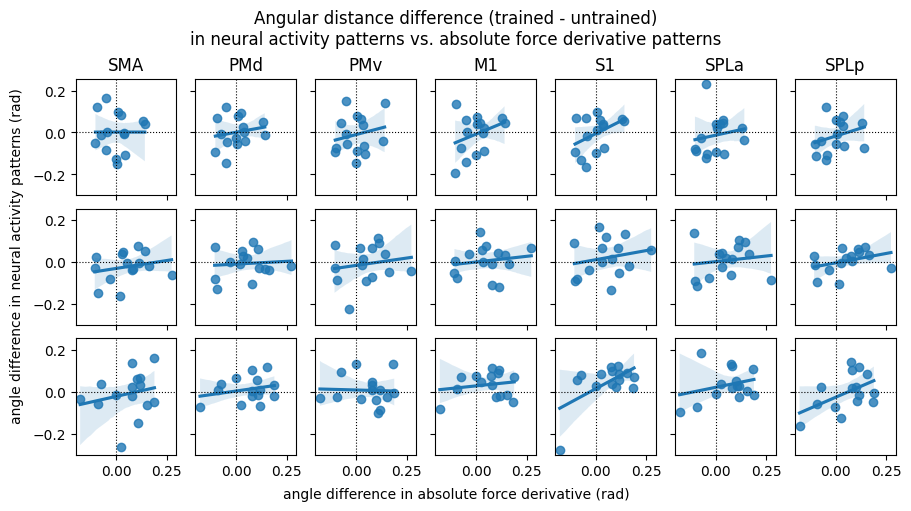

In [10]:
# difference in neural dissimilarities
stat  = 'theta'
dist_neural = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist_neural = dist_neural[(dist_neural.Hem=='L') & (dist_neural.chord.isin(hue_order))]
dist_neural_g = dist_neural.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()
dist_neural_trained   = dist_neural_g[dist_neural_g.chord=='trained'].reset_index(drop=True)
dist_neural_untrained = dist_neural_g[dist_neural_g.chord=='untrained'].reset_index(drop=True)
diff_neural         = dist_neural_trained.copy()
diff_neural         = diff_neural.merge(dist_neural_untrained, on=['session', 'sn', 'roi', 'Hem'])
diff_neural['Diff'] = diff_neural[f'{stat}_x'] - diff_neural[f'{stat}_y']

# difference in force dissimilarities
dist_force_g_der = dist_force_g[dist_force_g.metric=='der']
dist_force_trained   = dist_force_g_der[dist_force_g_der.chord=='trained'].reset_index(drop=True)
dist_force_untrained = dist_force_g_der[dist_force_g_der.chord=='untrained'].reset_index(drop=True)
diff_force         = dist_force_trained.copy()
diff_force         = diff_force.merge(dist_force_untrained, on=['session', 'sn',])
diff_force['Diff'] = diff_force[f'{stat}_x'] - diff_force[f'{stat}_y']
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, gl.sessions)}

fig, axs = plt.subplots(len(gl.sessions), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(gl.sessions):
                ax = axs[s, r]
                y    = diff_neural[(diff_neural.Hem==H) & (diff_neural.roi==roi) & (diff_neural.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].Diff.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('neural~force', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('angle difference in neural activity patterns (rad)', fontsize=10)
fig.supxlabel('angle difference in absolute force derivative (rad)', fontsize=10)

fig.suptitle('Angular distance difference (trained - untrained)\nin neural activity patterns vs. absolute force derivative patterns')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
                'tval':       res.tvalues['Intercept'],
                'pval':       res.pvalues['Intercept'],
        })
intercepts               = pd.DataFrame(records)
intercepts['regionname'] = pd.Categorical(intercepts.regionname, categories=gl.rois[atlas], ordered=True)
intercepts.sort_values(by=['session', 'regionname'], inplace=True)
print(intercepts)

plt.show()